# Chapter 1: Comparing Retrieval Models

We apply **four retrieval models** to the same query on the same collection,
so you can trace exactly how each one selects and ranks documents — and *why*
the rankings differ.

**Learning goals:**
- Implement and run Boolean, Extended Boolean, Vector Space (TF-IDF), and BM25 retrieval
- Understand each model's formula by stepping through the computation for concrete documents
- Identify each model's characteristic weakness (no ranking, repetition bias, length bias)
- Observe how BM25 addresses the limitations of simpler models

**Prerequisites:** Chapter 1.3-1.5 in the textbook; the feature extraction pipeline (ch01-01).

| Model | Type | Core idea |
|-------|------|-----------|
| Standard Boolean | Filter | Document is relevant (all terms) or not |
| Extended Boolean (P-norm) | Scoring | Graded evidence with soft AND/OR |
| Vector Space (TF-IDF + Cosine) | Scoring | Direction similarity in term-space |
| BM25 | Scoring | Probabilistic weighting with saturation |

In [1]:
from shared.synthetic_collection import MINI, documents
from shared.display import print_table, display_md
import re
import math
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

## Setup: Collection and Preprocessing

We use the same **MINI** collection and preprocessing as in ch01-01 (feature extraction).
No stemming — terms remain readable and lexical mismatches stay visible.

In [2]:
# --- Preprocessing (same as ch01-01) ---

STOPWORDS = {
    'a', 'an', 'the', 'and', 'or', 'in', 'of', 'to', 'for', 'is',
    'are', 'was', 'were', 'at', 'by', 'on', 'with', 'that', 'this',
    'it', 'from', 'as', 'be', 'has', 'have', 'had', 'not', 'but',
    'its', 'can', 'do', 'does', 'did', 'will', 'would', 'should',
    'may', 'might', 'he', 'she', 'they', 'we', 'you', 'i', 'me',
    'my', 'his', 'her', 'their', 'our', 'your',
}

def tokenize(text: str) -> list[str]:
    return [t for t in re.split(r'\W+', text.lower()) if t]

def remove_stopwords(tokens: list[str]) -> list[str]:
    return [t for t in tokens if t not in STOPWORDS]

# Build processed corpus
corpus = {
    doc_id: remove_stopwords(tokenize(text))
    for doc_id, text in MINI.items()
}

In [3]:
# Corpus statistics
def document_frequencies(corpus):
    df = Counter()
    for tokens in corpus.values():
        df.update(set(tokens))
    return dict(df)

df = document_frequencies(corpus)
vocab = sorted(df.keys())
N = len(corpus)
avg_dl = sum(len(t) for t in corpus.values()) / N

print(f"Documents: {N}")
print(f"Vocabulary: {len(vocab)} terms")
print(f"Average document length: {avg_dl:.1f} tokens")

Documents: 12
Vocabulary: 72 terms
Average document length: 9.7 tokens


## The Query

We use **"cat dog forest"** — a free-text query that intentionally spans multiple
documents and creates interesting differences between models.

In [4]:
query_text = "cat dog forest"
query_tokens = remove_stopwords(tokenize(query_text))
print(f"Query tokens: {query_tokens}")
print(f"Documents containing 'cat':    {[d for d, t in corpus.items() if 'cat' in t]}")
print(f"Documents containing 'dog':    {[d for d, t in corpus.items() if 'dog' in t]}")
print(f"Documents containing 'forest': {[d for d, t in corpus.items() if 'forest' in t]}")

Query tokens: ['cat', 'dog', 'forest']
Documents containing 'cat':    ['b1', 'b4', 'b9', 'b10', 'b12']
Documents containing 'dog':    ['b1', 'b3', 'b7', 'b9', 'b10', 'b12']
Documents containing 'forest': ['b1', 'b3', 'b5', 'b6', 'b8', 'b9', 'b10']


---
## Model 1: Standard Boolean

The Boolean model treats the query as a **logical predicate**. A document either
satisfies it completely or is excluded. There is no score — only a yes/no decision.

In [5]:
def boolean_and(query_terms: list[str], corpus: dict[str, list[str]]) -> list[str]:
    """Return doc_ids where ALL query terms are present."""
    results = []
    for doc_id, tokens in corpus.items():
        token_set = set(tokens)
        if all(t in token_set for t in query_terms):
            results.append(doc_id)
    return results

def boolean_or(query_terms: list[str], corpus: dict[str, list[str]]) -> list[str]:
    """Return doc_ids where ANY query term is present."""
    results = []
    for doc_id, tokens in corpus.items():
        token_set = set(tokens)
        if any(t in token_set for t in query_terms):
            results.append(doc_id)
    return results

In [6]:
results_and = boolean_and(query_tokens, corpus)
results_or = boolean_or(query_tokens, corpus)

display_md(f"**Boolean AND** (`cat AND dog AND forest`): **{len(results_and)} documents**")
if results_and:
    for doc_id in results_and:
        print(f"  {doc_id}: {MINI[doc_id]}")
else:
    display_md("*No documents contain ALL three terms!*")

print()
display_md(f"**Boolean OR** (`cat OR dog OR forest`): **{len(results_or)} documents**")
print_table(
    [[doc_id, MINI[doc_id][:55],
      ", ".join(t for t in query_tokens if t in set(corpus[doc_id]))]
     for doc_id in results_or],
    headers=["ID", "Document", "Matched Terms"]
)

**Boolean AND** (`cat AND dog AND forest`): **3 documents**

  b1: The Cat and Dog in the Forest. A cat and a dog begin a woodland adventure.
  b9: Cat Dog Forest.
  b10: Cat Dog Forest. A cat meets a dog in a forest beside rivers, mountains, castles, villages, bridges, and caves.



**Boolean OR** (`cat OR dog OR forest`): **10 documents**

| ID   | Document                                                | Matched Terms    |
|:-----|:--------------------------------------------------------|:-----------------|
| b1   | The Cat and Dog in the Forest. A cat and a dog begin a  | cat, dog, forest |
| b3   | The Forest Hound. A loyal dog follows a woodland trail  | dog, forest      |
| b4   | Feline Detective. A clever cat solves mysteries with a  | cat              |
| b5   | Random Forest for Pet Detection. A random forest model  | forest           |
| b6   | Forests of Search Trees. Algorithms explore a forest of | forest           |
| b7   | Dog Dog Dog! A dog chases a ball, finds a bone, and wak | dog              |
| b8   | Forest Forest Forest! A forest guide names trees, flowe | forest           |
| b9   | Cat Dog Forest.                                         | cat, dog, forest |
| b10  | Cat Dog Forest. A cat meets a dog in a forest beside ri | cat, dog, forest |
| b12  | The Pet Bakery. A cat, a dog, and a baker make cakes, b | cat, dog         |

**The Boolean problem:** AND is too strict (0 results from 3 terms), while OR is too
broad (10 out of 12 documents). Within the OR results, a document matching 1 term
looks the same as one matching 2. The user gets no guidance on which match is strongest.

---
## Model 2: Extended Boolean (P-Norm)

The Extended Boolean model keeps the Boolean query structure but replaces the
hard true/false with **graded scores between 0 and 1**. Documents matching more
query terms score higher; partial matches still receive positive scores.

The P-norm formula for AND measures how close a document is to the ideal (1,1,...,1):

$$\text{score}_{\text{AND}} = 1 - \sqrt[p]{\frac{\sum_{k=1}^{K}(1 - w_k)^p}{K}}$$

where $w_k$ is the normalized TF-IDF weight for query term $k$, and $p$ controls
strictness ($p=1$: average; $p \to \infty$: strict AND).

In [7]:
def extended_boolean_and(query_tokens, corpus, df, n, p=2):
    """
    Extended Boolean AND using the P-norm model.

    For each document, compute a normalized TF-IDF weight per query term,
    then combine using the p-norm AND formula.
    """
    K = len(query_tokens)
    results = []

    # Normalization constant: max possible tf*idf in the collection
    alpha = max(
        Counter(tokens).get(qt, 0) * math.log(n / df.get(qt, 1))
        for tokens in corpus.values()
        for qt in query_tokens
        if qt in df
    )
    if alpha == 0:
        alpha = 1

    for doc_id, tokens in corpus.items():
        tf = Counter(tokens)
        weights = []

        for qt in query_tokens:
            tf_val = tf.get(qt, 0)
            idf_val = math.log(n / df.get(qt, 1))
            raw = tf_val * idf_val
            # Normalize to [0, 1]
            w = min(1.0, raw / alpha) if alpha > 0 else 0.0
            weights.append(w)

        # P-norm AND: distance from the ideal point (1, 1, ..., 1)
        sum_term = sum((1 - w) ** p for w in weights) / K
        score = 1 - sum_term ** (1 / p)
        results.append((doc_id, score, weights))

    results.sort(key=lambda x: -x[1])
    return results

In [8]:
ext_results = extended_boolean_and(query_tokens, corpus, df, N, p=2)

display_md("**Extended Boolean AND (p=2)**")
print_table(
    [[rank+1, doc_id, f"{score:.4f}",
      " | ".join(f"{query_tokens[i]}={w:.3f}" for i, w in enumerate(weights)),
      MINI[doc_id][:45]]
     for rank, (doc_id, score, weights) in enumerate(ext_results) if score > 0],
    headers=["Rank", "ID", "Score", "Term weights (normalized)", "Document"]
)

**Extended Boolean AND (p=2)**

|   Rank | ID   |   Score | Term weights (normalized)            | Document                                      |
|-------:|:-----|--------:|:-------------------------------------|:----------------------------------------------|
|      1 | b10  |  0.4969 | cat=0.632 | dog=0.500 | forest=0.389 | Cat Dog Forest. A cat meets a dog in a forest |
|      2 | b1   |  0.4127 | cat=0.632 | dog=0.500 | forest=0.194 | The Cat and Dog in the Forest. A cat and a do |
|      3 | b9   |  0.2517 | cat=0.316 | dog=0.250 | forest=0.194 | Cat Dog Forest.                               |
|      4 | b7   |  0.1835 | cat=0.000 | dog=1.000 | forest=0.000 | Dog Dog Dog! A dog chases a ball, finds a bon |
|      5 | b12  |  0.1773 | cat=0.316 | dog=0.250 | forest=0.000 | The Pet Bakery. A cat, a dog, and a baker mak |
|      6 | b8   |  0.1735 | cat=0.000 | dog=0.000 | forest=0.778 | Forest Forest Forest! A forest guide names tr |
|      7 | b3   |  0.1414 | cat=0.000 | dog=0.250 | forest=0.194 | The Forest Hound. A loyal dog follows a woodl |
|      8 | b5   |  0.1105 | cat=0.000 | dog=0.000 | forest=0.389 | Random Forest for Pet Detection. A random for |
|      9 | b4   |  0.093  | cat=0.316 | dog=0.000 | forest=0.000 | Feline Detective. A clever cat solves mysteri |
|     10 | b6   |  0.0603 | cat=0.000 | dog=0.000 | forest=0.194 | Forests of Search Trees. Algorithms explore a |

**Key insight:** The Extended Boolean model gives **partial credit**. Documents with
all three terms (if any exist) score highest, but even single-term matches get
a positive score. The term weights show *why* each document scores as it does.

### Effect of parameter p

In [9]:
# Compare p=1 (lenient) vs p=2 (moderate) vs p=10 (strict)
display_md("**How does p affect the ranking?**")
rows = []
for doc_id in ["b1", "b9", "b10", "b7", "b4"]:
    row = [doc_id, MINI[doc_id][:40]]
    for p in [1, 2, 5, 10]:
        res = extended_boolean_and(query_tokens, corpus, df, N, p=p)
        score = next(s for d, s, _ in res if d == doc_id)
        row.append(f"{score:.3f}")
    rows.append(row)

print_table(rows, headers=["ID", "Document", "p=1", "p=2", "p=5", "p=10"])

**How does p affect the ranking?**

| ID   | Document                                 |   p=1 |   p=2 |   p=5 |   p=10 |
|:-----|:-----------------------------------------|------:|------:|------:|-------:|
| b1   | The Cat and Dog in the Forest. A cat and | 0.442 | 0.413 | 0.339 |  0.278 |
| b9   | Cat Dog Forest.                          | 0.253 | 0.252 | 0.247 |  0.24  |
| b10  | Cat Dog Forest. A cat meets a dog in a f | 0.507 | 0.497 | 0.472 |  0.445 |
| b7   | Dog Dog Dog! A dog chases a ball, finds  | 0.333 | 0.184 | 0.078 |  0.04  |
| b4   | Feline Detective. A clever cat solves my | 0.105 | 0.093 | 0.064 |  0.039 |

As p increases, the model becomes stricter: documents missing a query term
get penalized more heavily. At very high p, it approaches standard Boolean AND.

---
## Model 3: Vector Space Model (TF-IDF + Cosine)

The VSM represents query and documents as **vectors in term-space** and measures
similarity by the angle between them. No Boolean operators needed — just a
free-text query.

In [10]:
def tfidf_vector(tokens: list[str], df: dict[str, int], n: int, vocab: list[str]) -> list[float]:
    """TF-IDF vector aligned with vocabulary order."""
    tf = Counter(tokens)
    return [tf.get(t, 0) * math.log(n / df.get(t, 1)) for t in vocab]

def dot_product(v1, v2):
    """Inner product of two vectors."""
    return sum(a * b for a, b in zip(v1, v2))

def vector_norm(v):
    """Euclidean norm."""
    return math.sqrt(sum(x * x for x in v))

def cosine_similarity(v1, v2):
    """Cosine of angle between two vectors."""
    n1, n2 = vector_norm(v1), vector_norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    return dot_product(v1, v2) / (n1 * n2)

In [11]:
# Compute query vector and all document vectors
query_vec = tfidf_vector(query_tokens, df, N, vocab)
doc_vectors = {doc_id: tfidf_vector(tokens, df, N, vocab) for doc_id, tokens in corpus.items()}

# Rank by cosine similarity
vsm_results = [
    (doc_id, cosine_similarity(query_vec, doc_vectors[doc_id]),
     dot_product(query_vec, doc_vectors[doc_id]))
    for doc_id in corpus
]
vsm_results.sort(key=lambda x: -x[1])

display_md("**Vector Space Model (TF-IDF + Cosine)**")
print_table(
    [[rank+1, doc_id, f"{cos:.4f}", f"{dot:.4f}", MINI[doc_id][:45]]
     for rank, (doc_id, cos, dot) in enumerate(vsm_results) if cos > 0],
    headers=["Rank", "ID", "Cosine", "Inner Product", "Document"]
)

**Vector Space Model (TF-IDF + Cosine)**

|   Rank | ID   |   Cosine |   Inner Product | Document                                      |
|-------:|:-----|---------:|----------------:|:----------------------------------------------|
|      1 | b9   |   1      |          1.5374 | Cat Dog Forest.                               |
|      2 | b1   |   0.6588 |          2.7843 | The Cat and Dog in the Forest. A cat and a do |
|      3 | b10  |   0.342  |          3.0748 | Cat Dog Forest. A cat meets a dog in a forest |
|      4 | b7   |   0.2317 |          1.9218 | Dog Dog Dog! A dog chases a ball, finds a bon |
|      5 | b8   |   0.1387 |          1.1621 | Forest Forest Forest! A forest guide names tr |
|      6 | b12  |   0.137  |          1.2469 | The Pet Bakery. A cat, a dog, and a baker mak |
|      7 | b3   |   0.1025 |          0.771  | The Forest Hound. A loyal dog follows a woodl |
|      8 | b4   |   0.0932 |          0.7664 | Feline Detective. A clever cat solves mysteri |
|      9 | b5   |   0.059  |          0.581  | Random Forest for Pet Detection. A random for |
|     10 | b6   |   0.0343 |          0.2905 | Forests of Search Trees. Algorithms explore a |

### Why does cosine rank D9 highest?

Let's look at the actual vectors to understand:

In [12]:
# Show the vectors for b9, b1, and b10 (only non-zero query-term dimensions)
query_term_indices = [vocab.index(t) for t in query_tokens if t in vocab]

display_md("**Vectors for query terms only** (the dimensions that matter for scoring):")
rows = []
for doc_id in ["b9", "b1", "b10", "b7"]:
    tf = Counter(corpus[doc_id])
    row = [doc_id, len(corpus[doc_id])]
    for qt in query_tokens:
        row.append(f"{tf.get(qt, 0)}")
    row.append(f"{vector_norm(doc_vectors[doc_id]):.3f}")
    row.append(f"{cosine_similarity(query_vec, doc_vectors[doc_id]):.4f}")
    rows.append(row)

print_table(rows, headers=["ID", "Length", "tf(cat)", "tf(dog)", "tf(forest)", "||d||", "Cosine"])

**Vectors for query terms only** (the dimensions that matter for scoring):

| ID   |   Length |   tf(cat) |   tf(dog) |   tf(forest) |   ||d|| |   Cosine |
|:-----|---------:|----------:|----------:|-------------:|--------:|---------:|
| b9   |        3 |         1 |         1 |            1 |   1.24  |   1      |
| b1   |        8 |         2 |         2 |            1 |   3.408 |   0.6588 |
| b10  |       14 |         2 |         2 |            2 |   7.251 |   0.342  |
| b7   |       10 |         0 |         4 |            0 |   6.688 |   0.2317 |

**Explanation:** D9 contains *only* "cat", "dog", "forest" — its vector points in
exactly the same direction as the query. D10 has the same terms but also many others,
which increase ||d|| (the norm) and rotate the vector away from the query direction.
D7 has 4 occurrences of "dog" but nothing else relevant — high inner product but
low cosine because the direction is lopsided.

### Inner Product vs Cosine: Different rankings

In [13]:
# Sort by inner product instead
vsm_by_dot = sorted(vsm_results, key=lambda x: -x[2])

display_md("**Ranking difference: Inner Product vs Cosine**")
print_table(
    [[doc_id,
      f"#{next(i+1 for i,(d,_,_) in enumerate(vsm_by_dot) if d==doc_id)}",
      f"#{next(i+1 for i,(d,_,_) in enumerate(vsm_results) if d==doc_id)}",
      MINI[doc_id][:50]]
     for doc_id in ["b10", "b1", "b7", "b9"]],
    headers=["ID", "Rank (dot product)", "Rank (cosine)", "Document"]
)

**Ranking difference: Inner Product vs Cosine**

| ID   | Rank (dot product)   | Rank (cosine)   | Document                                           |
|:-----|:---------------------|:----------------|:---------------------------------------------------|
| b10  | #1                   | #3              | Cat Dog Forest. A cat meets a dog in a forest besi |
| b1   | #2                   | #2              | The Cat and Dog in the Forest. A cat and a dog beg |
| b7   | #3                   | #4              | Dog Dog Dog! A dog chases a ball, finds a bone, an |
| b9   | #4                   | #1              | Cat Dog Forest.                                    |

The inner product rewards **magnitude** (more terms = higher score), while cosine
rewards **direction** (query-like proportions). This is why long documents with
many query terms win under dot product, but short focused documents win under cosine.

---
## Model 4: BM25

BM25 combines three ideas that address the limitations above:
1. **Term frequency saturation** — diminishing returns for repetition
2. **Document length normalization** — shorter docs need fewer occurrences
3. **Probabilistic IDF** — derived from the Binary Independence Model

$$\text{BM25}(Q, D) = \sum_{t \in Q \cap D} \text{idf}(t) \cdot \frac{\text{tf}(t, D) \cdot (k_1+1)}{\text{tf}(t, D) + k_1 \cdot (1 - b + b \cdot |D|/\text{avgdl})}$$

In [14]:
def idf_bm25(term, df, n):
    """BM25 IDF (Lucene variant, always positive): log(1 + (N - df + 0.5) / (df + 0.5))"""
    d = df.get(term, 0)
    return math.log(1 + (n - d + 0.5) / (d + 0.5))

def bm25_score(query_tokens, doc_tokens, df, n, avg_dl, k1=1.2, b=0.75):
    """
    BM25 score for a single query-document pair.

    - k1: controls term frequency saturation (higher = more linear)
    - b: controls length normalization strength (0 = none, 1 = full)
    """
    tf = Counter(doc_tokens)
    dl = len(doc_tokens)
    score = 0.0

    for term in set(query_tokens):
        if term not in tf:
            continue
        tf_val = tf[term]
        idf_val = idf_bm25(term, df, n)
        # Saturating TF with length normalization
        numerator = tf_val * (k1 + 1)
        denominator = tf_val + k1 * (1 - b + b * dl / avg_dl)
        score += idf_val * numerator / denominator

    return score

### Step-by-step: BM25 for one document

Let's trace the full computation for D1 ("The Cat and Dog in the Forest..."):

In [15]:
doc_id = "b1"
tokens = corpus[doc_id]
tf = Counter(tokens)
dl = len(tokens)
k1, b = 1.2, 0.75

display_md(f"**BM25 step-by-step for {doc_id}** (length={dl}, avgdl={avg_dl:.1f})")
display_md(f"Document: *{MINI[doc_id]}*")
print()

total = 0.0
rows = []
for qt in query_tokens:
    tf_val = tf.get(qt, 0)
    idf_val = idf_bm25(qt, df, N)
    if tf_val > 0:
        num = tf_val * (k1 + 1)
        denom = tf_val + k1 * (1 - b + b * dl / avg_dl)
        tf_saturated = num / denom
        contribution = idf_val * tf_saturated
    else:
        tf_saturated = 0
        contribution = 0
    total += contribution
    rows.append([qt, tf_val, f"{idf_val:.3f}", f"{tf_saturated:.3f}", f"{contribution:.3f}"])

print_table(rows, headers=["Term", "tf", "IDF", "Saturated TF", "Contribution"])
print(f"\nTotal BM25 score: {total:.4f}")

**BM25 step-by-step for b1** (length=8, avgdl=9.7)

Document: *The Cat and Dog in the Forest. A cat and a dog begin a woodland adventure.*

| Term   |   tf |   IDF |   Saturated TF |   Contribution |
|:-------|-----:|------:|---------------:|---------------:|
| cat    |    2 | 0.86  |          1.445 |          1.243 |
| dog    |    2 | 0.693 |          1.445 |          1.002 |
| forest |    1 | 0.55  |          1.076 |          0.592 |


Total BM25 score: 2.8365


### BM25 ranking for all documents

In [16]:
bm25_results = [
    (doc_id, bm25_score(query_tokens, tokens, df, N, avg_dl))
    for doc_id, tokens in corpus.items()
]
bm25_results.sort(key=lambda x: -x[1])

display_md("**BM25 (k1=1.2, b=0.75)**")
print_table(
    [[rank+1, doc_id, f"{score:.4f}", len(corpus[doc_id]), MINI[doc_id][:45]]
     for rank, (doc_id, score) in enumerate(bm25_results) if score > 0],
    headers=["Rank", "ID", "Score", "Length", "Document"]
)

**BM25 (k1=1.2, b=0.75)**

|   Rank | ID   |   Score |   Length | Document                                      |
|-------:|:-----|--------:|---------:|:----------------------------------------------|
|      1 | b9   |  2.9301 |        3 | Cat Dog Forest.                               |
|      2 | b1   |  2.8365 |        8 | The Cat and Dog in the Forest. A cat and a do |
|      3 | b10  |  2.5684 |       14 | Cat Dog Forest. A cat meets a dog in a forest |
|      4 | b12  |  1.4704 |       11 | The Pet Bakery. A cat, a dog, and a baker mak |
|      5 | b3   |  1.2259 |       10 | The Forest Hound. A loyal dog follows a woodl |
|      6 | b7   |  1.1661 |       10 | Dog Dog Dog! A dog chases a ball, finds a bon |
|      7 | b4   |  0.9255 |        8 | Feline Detective. A clever cat solves mysteri |
|      8 | b8   |  0.8935 |       12 | Forest Forest Forest! A forest guide names tr |
|      9 | b5   |  0.7281 |       11 | Random Forest for Pet Detection. A random for |
|     10 | b6   |  0.5424 |       10 | Forests of Search Trees. Algorithms explore a |

### Why BM25 fixes the problems

**Term-frequency saturation:** How does repeating 'dog' affect the score?

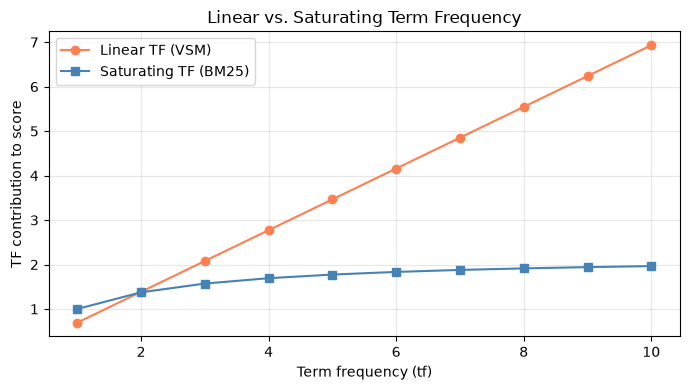

In [17]:
# Show term-frequency saturation for "dog"
display_md("**Term-frequency saturation:** How does repeating 'dog' affect the score?")

tf_range = range(1, 11)
linear_scores = [tf_val * math.log(N / df.get("dog", 1)) for tf_val in tf_range]
bm25_tf = [tf_val * (k1 + 1) / (tf_val + k1) for tf_val in tf_range]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tf_range, linear_scores, "o-", label="Linear TF (VSM)", color="coral")
ax.plot(tf_range, bm25_tf, "s-", label="Saturating TF (BM25)", color="steelblue")
ax.set_xlabel("Term frequency (tf)")
ax.set_ylabel("TF contribution to score")
ax.set_title("Linear vs. Saturating Term Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Show length normalization: same tf=1, different document lengths
display_md("**Length normalization:** Same tf=1 for 'dog', but different doc lengths:")

lengths = [3, 5, 8, 10, 15, 20, 30]
scores_by_length = []
for dl in lengths:
    denom = 1 + k1 * (1 - b + b * dl / avg_dl)
    tf_contrib = (k1 + 1) / denom
    scores_by_length.append(tf_contrib)

print_table(
    [[dl, f"{dl/avg_dl:.2f}", f"{s:.3f}"]
     for dl, s in zip(lengths, scores_by_length)],
    headers=["Doc length", "dl/avgdl", "Saturated TF (tf=1)"]
)

**Length normalization:** Same tf=1 for 'dog', but different doc lengths:

|   Doc length |   dl/avgdl |   Saturated TF (tf=1) |
|-------------:|-----------:|----------------------:|
|            3 |       0.31 |                 1.393 |
|            5 |       0.52 |                 1.246 |
|            8 |       0.83 |                 1.076 |
|           10 |       1.03 |                 0.986 |
|           15 |       1.55 |                 0.816 |
|           20 |       2.07 |                 0.696 |
|           30 |       3.1  |                 0.537 |

A single occurrence of "dog" in a 3-token document contributes **more** than in a
20-token document, because that occurrence covers a larger fraction of the content.

---
## Side-by-Side Comparison

Let's compare all models on the same query to see their different behaviors:

In [19]:
# Collect all rankings
def get_rank_score(results, doc_id):
    """Get rank and score for a doc_id from a result list."""
    for i, item in enumerate(results):
        d = item[0]
        s = item[1]
        if d == doc_id and s > 0:
            return i + 1, s
    return None, 0

# Documents of interest (appear in at least one ranking)
interesting_docs = ["b9", "b1", "b10", "b7", "b12", "b3", "b4", "b8"]

rows = []
for doc_id in interesting_docs:
    in_and = "Yes" if doc_id in results_and else ""
    in_or = "Yes" if doc_id in results_or else ""

    ext_rank, ext_score = get_rank_score([(d,s) for d,s,_ in ext_results], doc_id)
    vsm_rank, vsm_score = get_rank_score([(d,c) for d,c,_ in vsm_results], doc_id)
    bm25_rank, bm25_score_val = get_rank_score(bm25_results, doc_id)

    rows.append([
        doc_id,
        MINI[doc_id][:35],
        in_and,
        in_or,
        f"#{ext_rank} ({ext_score:.3f})" if ext_rank else "-",
        f"#{vsm_rank} ({vsm_score:.3f})" if vsm_rank else "-",
        f"#{bm25_rank} ({bm25_score_val:.3f})" if bm25_rank else "-",
    ])

display_md(f'**Query: "{query_text}"**')
print_table(rows,
    headers=["ID", "Document", "AND", "OR", "Ext. Bool", "VSM (cos)", "BM25"]
)

**Query: "cat dog forest"**

| ID   | Document                            | AND   | OR   | Ext. Bool   | VSM (cos)   | BM25       |
|:-----|:------------------------------------|:------|:-----|:------------|:------------|:-----------|
| b9   | Cat Dog Forest.                     | Yes   | Yes  | #3 (0.252)  | #1 (1.000)  | #1 (2.930) |
| b1   | The Cat and Dog in the Forest. A ca | Yes   | Yes  | #2 (0.413)  | #2 (0.659)  | #2 (2.836) |
| b10  | Cat Dog Forest. A cat meets a dog i | Yes   | Yes  | #1 (0.497)  | #3 (0.342)  | #3 (2.568) |
| b7   | Dog Dog Dog! A dog chases a ball, f |       | Yes  | #4 (0.184)  | #4 (0.232)  | #6 (1.166) |
| b12  | The Pet Bakery. A cat, a dog, and a |       | Yes  | #5 (0.177)  | #6 (0.137)  | #4 (1.470) |
| b3   | The Forest Hound. A loyal dog follo |       | Yes  | #7 (0.141)  | #7 (0.102)  | #5 (1.226) |
| b4   | Feline Detective. A clever cat solv |       | Yes  | #9 (0.093)  | #8 (0.093)  | #7 (0.925) |
| b8   | Forest Forest Forest! A forest guid |       | Yes  | #6 (0.173)  | #5 (0.139)  | #8 (0.894) |

---
## Deep Dive: Why Do Rankings Differ?

Let's pick three documents and trace *why* each model ranks them differently:

In [20]:
display_md("""
**D9** = "Cat Dog Forest." (3 tokens)
**D7** = "Dog Dog Dog! A dog chases..." (repeats "dog" 4x)
**D10** = "Cat Dog Forest. A cat meets a dog..." (14 tokens, all terms repeated)

| Aspect | D9 | D7 | D10 |
|--------|----|----|-----|
| Query term coverage | All 3 | Only "dog" | All 3 |
| Document length | Very short (3) | Medium (10) | Long (14) |
| Term frequency | 1 each | 4x "dog" | 2x each |
""")


**D9** = "Cat Dog Forest." (3 tokens)
**D7** = "Dog Dog Dog! A dog chases..." (repeats "dog" 4x)
**D10** = "Cat Dog Forest. A cat meets a dog..." (14 tokens, all terms repeated)

| Aspect | D9 | D7 | D10 |
|--------|----|----|-----|
| Query term coverage | All 3 | Only "dog" | All 3 |
| Document length | Very short (3) | Medium (10) | Long (14) |
| Term frequency | 1 each | 4x "dog" | 2x each |


In [21]:
display_md("**Why each model prefers a different winner:**")
display_md("""
- **VSM (cosine)** picks **D9** because its vector has exactly the same direction as the query.
  The short length means no non-query terms dilute the norm.

- **VSM (inner product)** picks **D10** because it has the highest raw tf-idf values
  (2x each term). Inner product rewards magnitude, not direction.

- **BM25** picks **D9** because: (1) saturation prevents D7's repetition from dominating,
  and (2) length normalization gives D9 credit for covering all terms in fewer tokens.
  D10 is close but its extra length slightly reduces each term's contribution.

- **Extended Boolean** picks **D1** or **D10** because it normalizes weights to [0,1] and
  rewards balanced coverage, but its alpha normalization can favor repeated terms differently.
""")

**Why each model prefers a different winner:**


- **VSM (cosine)** picks **D9** because its vector has exactly the same direction as the query.
  The short length means no non-query terms dilute the norm.

- **VSM (inner product)** picks **D10** because it has the highest raw tf-idf values
  (2x each term). Inner product rewards magnitude, not direction.

- **BM25** picks **D9** because: (1) saturation prevents D7's repetition from dominating,
  and (2) length normalization gives D9 credit for covering all terms in fewer tokens.
  D10 is close but its extra length slightly reduces each term's contribution.

- **Extended Boolean** picks **D1** or **D10** because it normalizes weights to [0,1] and
  rewards balanced coverage, but its alpha normalization can favor repeated terms differently.


---
## Parameter Exploration: BM25's k1 and b

In [22]:
display_md("**Effect of k1** (saturation speed) and **b** (length normalization):")

# Vary k1 with fixed b=0.75
k1_values = [0.5, 1.0, 1.2, 2.0, 5.0, 100.0]
rows = []
for doc_id in ["b9", "b1", "b10", "b7"]:
    row = [doc_id, len(corpus[doc_id])]
    for k1_val in k1_values:
        s = bm25_score(query_tokens, corpus[doc_id], df, N, avg_dl, k1=k1_val, b=0.75)
        row.append(f"{s:.3f}")
    rows.append(row)

display_md("*Varying k1 (b=0.75 fixed):*")
print_table(rows, headers=["ID", "Len"] + [f"k1={k}" for k in k1_values])

**Effect of k1** (saturation speed) and **b** (length normalization):

*Varying k1 (b=0.75 fixed):*

| ID   |   Len |   k1=0.5 |   k1=1.0 |   k1=1.2 |   k1=2.0 |   k1=5.0 |   k1=100.0 |
|:-----|------:|---------:|---------:|---------:|---------:|---------:|-----------:|
| b9   |     3 |    2.542 |    2.837 |    2.93  |    3.21  |    3.697 |      4.311 |
| b1   |     8 |    2.488 |    2.752 |    2.836 |    3.093 |    3.55  |      4.154 |
| b10  |    14 |    2.365 |    2.522 |    2.568 |    2.701 |    2.908 |      3.133 |
| b7   |    10 |    0.922 |    1.103 |    1.166 |    1.374 |    1.822 |      2.627 |

In [23]:
# Vary b with fixed k1=1.2
b_values = [0.0, 0.25, 0.5, 0.75, 1.0]
rows = []
for doc_id in ["b9", "b1", "b10", "b7"]:
    row = [doc_id, len(corpus[doc_id])]
    for b_val in b_values:
        s = bm25_score(query_tokens, corpus[doc_id], df, N, avg_dl, k1=1.2, b=b_val)
        row.append(f"{s:.3f}")
    rows.append(row)

display_md("*Varying b (k1=1.2 fixed):*")
print_table(rows, headers=["ID", "Len"] + [f"b={b_val}" for b_val in b_values])

*Varying b (k1=1.2 fixed):*

| ID   |   Len |   b=0.0 |   b=0.25 |   b=0.5 |   b=0.75 |   b=1.0 |
|:-----|------:|--------:|---------:|--------:|---------:|--------:|
| b9   |     3 |   2.103 |    2.322 |   2.591 |    2.93  |   3.372 |
| b1   |     8 |   2.686 |    2.734 |   2.784 |    2.836 |   2.891 |
| b10  |    14 |   2.892 |    2.776 |   2.668 |    2.568 |   2.476 |
| b7   |    10 |   1.173 |    1.171 |   1.168 |    1.166 |   1.164 |

In [24]:
display_md("""
**Interpretation:**
- **k1 small** (0.5): heavy saturation, repetition barely helps. All docs with the same term set score similarly.
- **k1 large** (100): almost linear TF, like VSM. Repetition dominates.
- **b=0**: no length normalization. Short and long documents with same tf score the same.
- **b=1**: full normalization. Short documents get maximum benefit.

Production default: **k1=1.2, b=0.75** — a well-tested compromise.
""")


**Interpretation:**
- **k1 small** (0.5): heavy saturation, repetition barely helps. All docs with the same term set score similarly.
- **k1 large** (100): almost linear TF, like VSM. Repetition dominates.
- **b=0**: no length normalization. Short and long documents with same tf score the same.
- **b=1**: full normalization. Short documents get maximum benefit.

Production default: **k1=1.2, b=0.75** — a well-tested compromise.


---
## Lessons Learned

| Model | Strengths | Weaknesses | When to use |
|-------|-----------|------------|-------------|
| **Standard Boolean** | Precise, fast, explainable | No ranking, no partial match | Filtering (facets, metadata) |
| **Extended Boolean** | Ranked + Boolean query structure | Heuristic normalization, sensitive to p | Rarely used alone; historical interest |
| **VSM (cosine)** | Natural free-text queries, partial match | No TF saturation, length penalizes non-query terms | Baselines, clustering, recommendation |
| **BM25** | Saturation + length norm + principled IDF | Still lexical, no semantics | Production search, RAG first-stage |

**The historical progression:** Boolean (1960s) solved filtering. VSM (1970s) added ranking.
BM25 (1994) added principled weighting. Each model addresses a specific limitation of
its predecessor — but all remain limited to *lexical* matching (exact token identity).

**Next:** Chapter 2 introduces evaluation metrics that let us measure *how much better*
one model's ranking actually is. Chapter 5 introduces *semantic* representations that
bridge the vocabulary gap entirely.

---
## Try It Yourself

Change the query and re-run to see how the models respond differently:

In [25]:
# Suggested queries to try:
# - "dog"             (single term — how do models handle it?)
# - "cat dog"         (2 terms — watch Boolean AND vs OR)
# - "random forest"   (technical meaning — all models get confused)
# - "ancient trees"   (partial overlap with several docs)
# - "kitten puppy"    (synonyms of cat/dog — none match!)

my_query = "cat dog"
my_tokens = remove_stopwords(tokenize(my_query))
print(f"Query: '{my_query}' -> tokens: {my_tokens}")
print()

# Boolean
print(f"Boolean AND: {boolean_and(my_tokens, corpus)}")
print(f"Boolean OR:  {boolean_or(my_tokens, corpus)}")
print()

# Ranked models - top 5
my_ext = extended_boolean_and(my_tokens, corpus, df, N, p=2)
my_query_vec = tfidf_vector(my_tokens, df, N, vocab)
my_vsm = sorted(
    [(d, cosine_similarity(my_query_vec, doc_vectors[d])) for d in corpus],
    key=lambda x: -x[1]
)
my_bm25 = sorted(
    [(d, bm25_score(my_tokens, t, df, N, avg_dl)) for d, t in corpus.items()],
    key=lambda x: -x[1]
)

for name, results in [("Ext. Boolean", [(d,s) for d,s,_ in my_ext]),
                       ("VSM (cosine)", my_vsm),
                       ("BM25", my_bm25)]:
    top = [(d, s) for d, s in results[:5] if s > 0]
    print(f"{name}:")
    for d, s in top:
        print(f"  {d} ({s:.4f}): {MINI[d][:60]}")
    print()

Query: 'cat dog' -> tokens: ['cat', 'dog']

Boolean AND: ['b1', 'b9', 'b10', 'b12']
Boolean OR:  ['b1', 'b3', 'b4', 'b7', 'b9', 'b10', 'b12']

Ext. Boolean:
  b1 (0.5608): The Cat and Dog in the Forest. A cat and a dog begin a woodl
  b10 (0.5608): Cat Dog Forest. A cat meets a dog in a forest beside rivers,
  b7 (0.2929): Dog Dog Dog! A dog chases a ball, finds a bone, and wakes th
  b9 (0.2821): Cat Dog Forest.
  b12 (0.2821): The Pet Bakery. A cat, a dog, and a baker make cakes, bread,

VSM (cosine):
  b9 (0.9006): Cat Dog Forest.
  b1 (0.6552): The Cat and Dog in the Forest. A cat and a dog begin a woodl
  b10 (0.3080): Cat Dog Forest. A cat meets a dog in a forest beside rivers,
  b7 (0.2573): Dog Dog Dog! A dog chases a ball, finds a bone, and wakes th
  b12 (0.1522): The Pet Bakery. A cat, a dog, and a baker make cakes, bread,

BM25:
  b1 (2.2447): The Cat and Dog in the Forest. A cat and a dog begin a woodl
  b9 (2.1638): Cat Dog Forest.
  b10 (1.8967): Cat Dog Forest. A cat me